In [9]:
import sys
!{sys.executable} -m pip install xgboost shap

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
  Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
Using cached shap-0.52.0-cp312-abi3-macosx_11_0_arm64.whl (490 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]━━━━━━━━━━━━━ 2/3 [shap]


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, precision_recall_curve,
                              RocCurveDisplay)
import xgboost as xgb
import shap

# Load final feature matrix
df = pd.read_csv('../data/processed/final_features.csv')

# Split features and target
X = df.drop('stress_label', axis=1)
y = df['stress_label']

print("✅ Data loaded")
print(f"Features: {X.shape}")
print(f"Target: {y.shape}")
print(f"Stress rate: {y.mean():.1%}")
print(f"\nFeature list:\n{list(X.columns)}")

✅ Data loaded
Features: (51336, 26)
Target: (51336,)
Stress rate: 37.3%

Feature list:
['delinquency_severity', 'delinq_trend', 'dpd_stress', 'cc_utilization_risk', 'pl_utilization_risk', 'credit_stress_score', 'unsecured_loan_ratio', 'recent_loan_hunger', 'closure_rate', 'missed_payment_ratio', 'market_volatility_score', 'enquiry_acceleration', 'enquiry_rejection_proxy', 'debt_burden', 'income_employment_score', 'Credit_Score', 'NETMONTHLYINCOME', 'AGE', 'Time_With_Curr_Empr', 'Tot_Active_TL', 'Tot_Closed_TL', 'CC_utilization', 'PL_utilization', 'num_times_delinquent', 'tot_enq', 'max_unsec_exposure_inPct']


In [11]:
# ── TRAIN/TEST SPLIT ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train stress rate: {y_train.mean():.1%}")
print(f"Test stress rate:  {y_test.mean():.1%}")

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── BASELINE: LOGISTIC REGRESSION ────────────────────────────────
print("\nTraining Logistic Regression baseline...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)
lr_auc   = roc_auc_score(y_test, lr_probs)

print(f"\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"AUC-ROC: {lr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_preds))

Train size: (41068, 26)
Test size:  (10268, 26)
Train stress rate: 37.3%
Test stress rate:  37.3%

Training Logistic Regression baseline...

=== LOGISTIC REGRESSION RESULTS ===
AUC-ROC: 0.7325

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.76      6440
           1       0.60      0.59      0.59      3828

    accuracy                           0.70     10268
   macro avg       0.68      0.68      0.68     10268
weighted avg       0.70      0.70      0.70     10268



In [12]:
# ── XGBOOST MODEL ─────────────────────────────────────────────────
print("Training XGBoost...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)
xgb_auc   = roc_auc_score(y_test, xgb_probs)

print(f"\n=== XGBOOST RESULTS ===")
print(f"AUC-ROC: {xgb_auc:.4f}")
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_preds))

# Precision at top decile — most important metric for lenders
sorted_idx = np.argsort(xgb_probs)[::-1]
top_decile = int(len(y_test) * 0.10)
top_decile_precision = y_test.iloc[sorted_idx[:top_decile]].mean()
print(f"Precision @ Top 10% riskiest: {top_decile_precision:.1%}")

# Model comparison
print(f"\n=== MODEL COMPARISON ===")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc:.4f}")
print(f"Improvement:             +{(xgb_auc - lr_auc):.4f}")

Training XGBoost...

=== XGBOOST RESULTS ===
AUC-ROC: 1.0000
Best iteration: 0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6440
           1       1.00      1.00      1.00      3828

    accuracy                           1.00     10268
   macro avg       1.00      1.00      1.00     10268
weighted avg       1.00      1.00      1.00     10268

Precision @ Top 10% riskiest: 100.0%

=== MODEL COMPARISON ===
Logistic Regression AUC: 0.7325
XGBoost AUC:             1.0000
Improvement:             +0.2675


In [13]:
# ── FIX DATA LEAKAGE ─────────────────────────────────────────────
# The Approved_Flag derived columns are leaking the target
# Also Credit_Score might be too directly tied to approval
# Let's check feature correlations with target

correlation_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print("Top 15 features most correlated with target:")
print(correlation_with_target.head(15).round(4))

Top 15 features most correlated with target:
enquiry_acceleration       0.3181
tot_enq                    0.2225
enquiry_rejection_proxy    0.1942
Credit_Score               0.1724
Tot_Active_TL              0.1377
recent_loan_hunger         0.1308
Tot_Closed_TL              0.1212
unsecured_loan_ratio       0.1035
credit_stress_score        0.1023
num_times_delinquent       0.0976
dpd_stress                 0.0802
missed_payment_ratio       0.0777
delinquency_severity       0.0767
closure_rate               0.0682
delinq_trend               0.0477
dtype: float64


In [14]:
# Check if Approved_Flag leaked into features
print("Columns in X:")
print(list(X.columns))
print()

# Check if any column contains Approved_Flag encoded values
approved_cols = [c for c in X.columns if 'Approved' in c or 'approved' in c or 'P1' in c or 'P2' in c]
print(f"Suspicious columns: {approved_cols}")

# Also check - did the merged dataframe have Approved_Flag as a column
# that got one-hot encoded into X?
print(f"\nTotal columns in df: {len(df.columns)}")
print(f"All columns:\n{list(df.columns)}")

Columns in X:
['delinquency_severity', 'delinq_trend', 'dpd_stress', 'cc_utilization_risk', 'pl_utilization_risk', 'credit_stress_score', 'unsecured_loan_ratio', 'recent_loan_hunger', 'closure_rate', 'missed_payment_ratio', 'market_volatility_score', 'enquiry_acceleration', 'enquiry_rejection_proxy', 'debt_burden', 'income_employment_score', 'Credit_Score', 'NETMONTHLYINCOME', 'AGE', 'Time_With_Curr_Empr', 'Tot_Active_TL', 'Tot_Closed_TL', 'CC_utilization', 'PL_utilization', 'num_times_delinquent', 'tot_enq', 'max_unsec_exposure_inPct']

Suspicious columns: []

Total columns in df: 27
All columns:
['delinquency_severity', 'delinq_trend', 'dpd_stress', 'cc_utilization_risk', 'pl_utilization_risk', 'credit_stress_score', 'unsecured_loan_ratio', 'recent_loan_hunger', 'closure_rate', 'missed_payment_ratio', 'market_volatility_score', 'enquiry_acceleration', 'enquiry_rejection_proxy', 'debt_burden', 'income_employment_score', 'Credit_Score', 'NETMONTHLYINCOME', 'AGE', 'Time_With_Curr_Empr',

In [15]:
# Credit_Score is likely too predictive - it's a direct bureau output
# that already encodes the approval decision. Remove it and retrain.

print("Credit Score distribution by stress label:")
print(df.groupby('stress_label')['Credit_Score'].describe().round(1))

# Remove Credit_Score as it's derived from the same approval process
X_clean = X.drop(columns=['Credit_Score'])
print(f"\nFeatures after removing Credit_Score: {X_clean.shape[1]}")

# Retrain split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_clean, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain XGBoost
xgb_model2 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=y_train2.value_counts()[0] / y_train2.value_counts()[1],
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

xgb_model2.fit(
    X_train2, y_train2,
    eval_set=[(X_test2, y_test2)],
    verbose=False
)

xgb_probs2 = xgb_model2.predict_proba(X_test2)[:, 1]
xgb_preds2 = xgb_model2.predict(X_test2)
xgb_auc2   = roc_auc_score(y_test2, xgb_probs2)

print(f"\n=== XGBOOST RESULTS (without Credit_Score) ===")
print(f"AUC-ROC: {xgb_auc2:.4f}")
print(f"Best iteration: {xgb_model2.best_iteration}")
print(f"\nClassification Report:")
print(classification_report(y_test2, xgb_preds2))

# Precision at top decile
sorted_idx2 = np.argsort(xgb_probs2)[::-1]
top_decile2 = int(len(y_test2) * 0.10)
top_decile_precision2 = y_test2.iloc[sorted_idx2[:top_decile2]].mean()
print(f"Precision @ Top 10% riskiest: {top_decile_precision2:.1%}")

print(f"\n=== FINAL MODEL COMPARISON ===")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"XGBoost AUC:             {xgb_auc2:.4f}")
print(f"Improvement:             +{(xgb_auc2 - lr_auc):.4f}")

Credit Score distribution by stress label:
                count   mean   std    min    25%    50%    75%    max
stress_label                                                         
0             32199.0  682.6   8.3  669.0  676.0  682.0  689.0  700.0
1             19137.0  675.3  31.3  469.0  656.0  665.0  705.0  811.0

Features after removing Credit_Score: 25

=== XGBOOST RESULTS (without Credit_Score) ===
AUC-ROC: 0.8219
Best iteration: 291

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78      6440
           1       0.63      0.72      0.67      3828

    accuracy                           0.74     10268
   macro avg       0.73      0.74      0.73     10268
weighted avg       0.75      0.74      0.74     10268

Precision @ Top 10% riskiest: 90.9%

=== FINAL MODEL COMPARISON ===
Logistic Regression AUC: 0.7325
XGBoost AUC:             0.8219
Improvement:             +0.0893


Computing SHAP values (takes 1-2 minutes)...


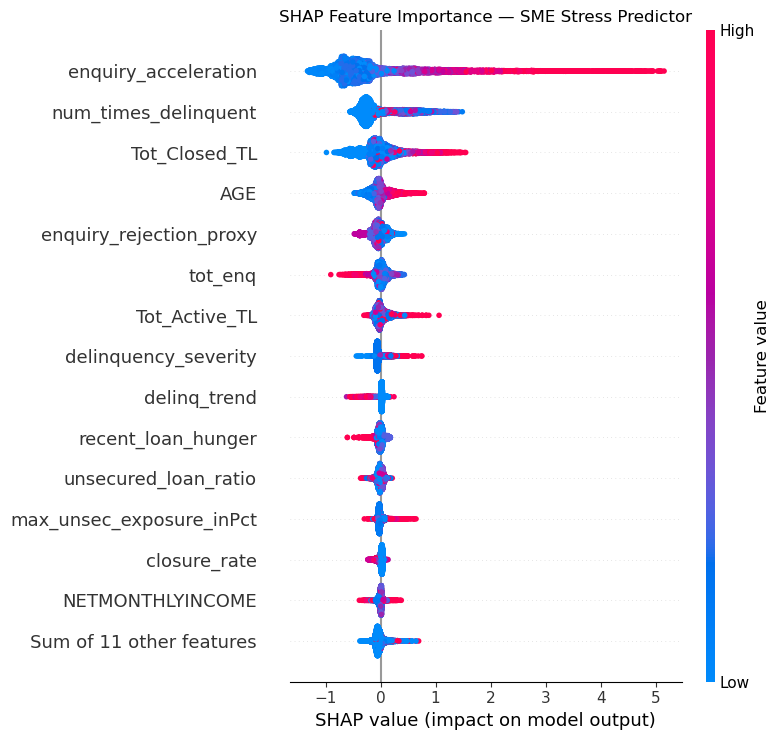

✅ Beeswarm plot saved


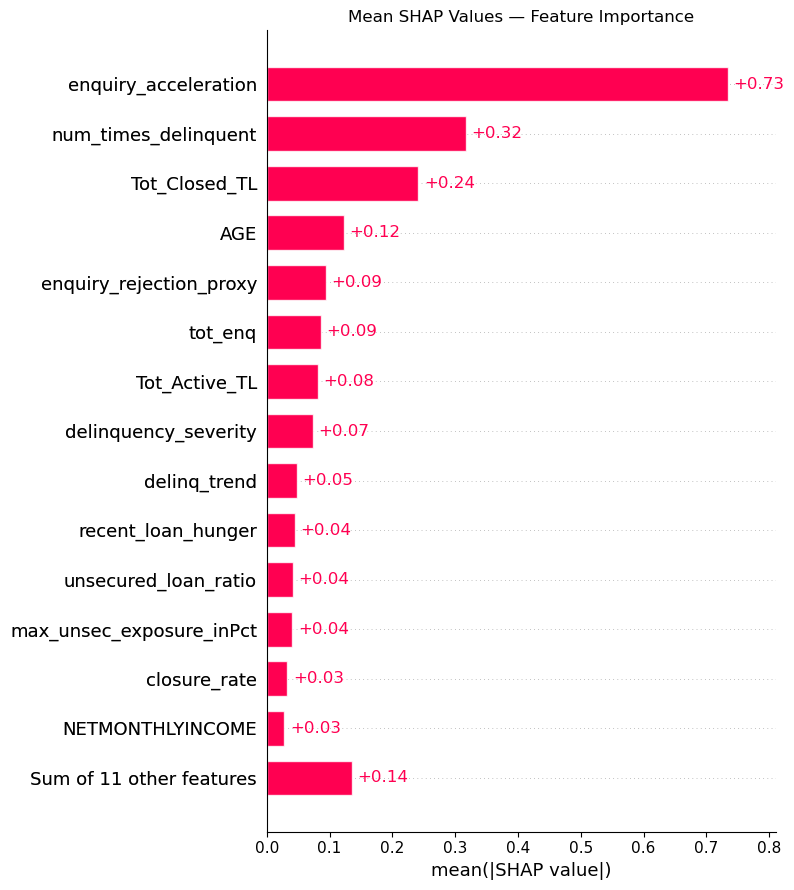

✅ Bar plot saved

High-risk firm explanation:


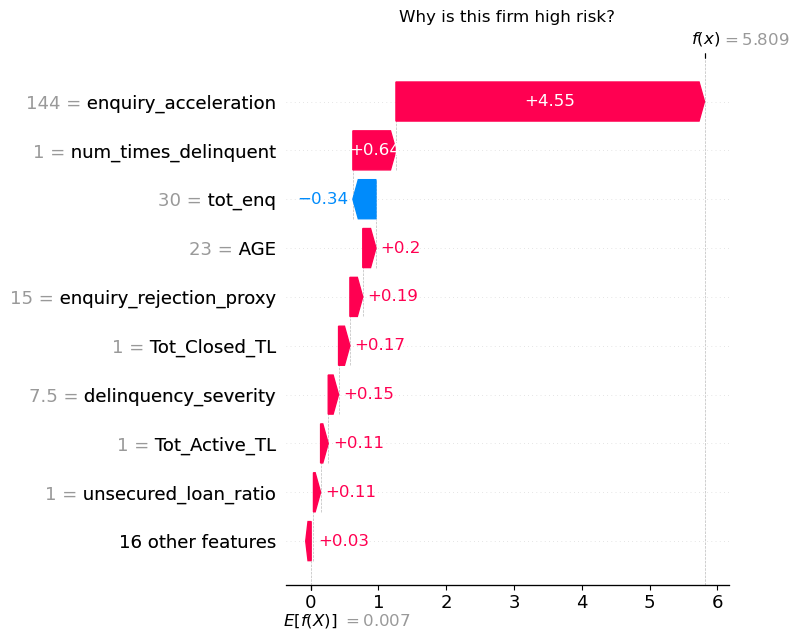

✅ Waterfall plot saved


In [16]:
# ── SHAP EXPLAINABILITY ───────────────────────────────────────────
print("Computing SHAP values (takes 1-2 minutes)...")

explainer = shap.TreeExplainer(xgb_model2)
shap_values = explainer(X_test2)

# Plot 1 — Beeswarm (global feature importance)
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance — SME Stress Predictor")
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Beeswarm plot saved")

# Plot 2 — Bar plot (mean absolute SHAP)
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Mean SHAP Values — Feature Importance")
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar plot saved")

# Plot 3 — Waterfall for single high-risk firm
print("\nHigh-risk firm explanation:")
high_risk_idx = np.argsort(xgb_probs2)[::-1][0]
plt.figure()
shap.plots.waterfall(shap_values[high_risk_idx], show=False)
plt.title("Why is this firm high risk?")
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_highrisk.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved")